# 🏨 NaraHoteis — Consultoria de Dados
## Diagnóstico e Painel Gerencial

**Cliente:** NaraHoteis — Rede Hoteleira do Estado do Rio de Janeiro  
**Documento de referência:** COM-2025-047 (Comunicado Oficial do Departamento de TI)  
**Guia utilizado:** Guia de Boas Práticas — Tratamento de Dados (NaraHoteis)

---

### Sumário

1. [Importações e Carregamento das Bases](#1-importações-e-carregamento-das-bases)
2. [Auditoria Geral](#2-auditoria-geral)
3. [Pré-processamento — reservas.csv](#3-pré-processamento--reservascsv)
4. [Pré-processamento — unidades.csv](#4-pré-processamento--unidadescsv)
5. [Pré-processamento — tipos_quarto.csv](#5-pré-processamento--tipos_quartocsv)
6. [Pré-processamento — clientes.csv](#6-pré-processamento--clientescsv)
7. [Pré-processamento — canais_venda.csv](#7-pré-processamento--canais_vendacsv)
8. [Pré-processamento — funcionarios.csv](#8-pré-processamento--funcionarioscsv)
9. [Exportação das Bases Tratadas](#9-exportação-das-bases-tratadas)
10. [Análise Estatística](#10-análise-estatística)
11. [Painel — Matplotlib](#11-painel--matplotlib)


---
## 1. Importações e Carregamento das Bases

In [367]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [368]:
reservas     = pd.read_csv('../NARA-HOTEIS/brutos/reservas.csv', sep=';')
unidades     = pd.read_csv('../NARA-HOTEIS/brutos/unidades.csv', sep=';')
tipos_quarto = pd.read_csv('../NARA-HOTEIS/brutos/tipos_quarto.csv', sep=';')
clientes     = pd.read_csv('../NARA-HOTEIS/brutos/clientes.csv', sep=';')
canais_venda = pd.read_csv('../NARA-HOTEIS/brutos/canais_venda.csv', sep=';')
funcionarios = pd.read_csv('../NARA-HOTEIS/brutos/funcionarios.csv', sep=';')

---
## 2. Auditoria Geral

Antes de qualquer tratamento, auditamos todas as bases para mapear volume, tipos de colunas e valores nulos.

In [369]:
print("=== RESERVAS ===")
print(reservas.shape)
print(reservas.dtypes)
print(reservas.isnull().sum())

=== RESERVAS ===
(2457, 12)
id_reserva             int64
id_unidade             int64
id_tipo_quarto         int64
id_cliente             int64
id_canal             float64
data_checkin             str
data_checkout            str
qtd_diarias            int64
num_hospedes           int64
avaliacao_hospede    float64
status_reserva           str
forma_pagamento          str
dtype: object
id_reserva             0
id_unidade             0
id_tipo_quarto         0
id_cliente             0
id_canal             112
data_checkin           0
data_checkout          0
qtd_diarias            0
num_hospedes           0
avaliacao_hospede    337
status_reserva         0
forma_pagamento        0
dtype: int64


In [370]:
print("=== UNIDADES ===")
print(unidades.shape)
print(unidades.dtypes)
print(unidades.isnull().sum())

=== UNIDADES ===
(12, 6)
id_unidade             int64
nome_unidade             str
cidade                   str
regiao                   str
categoria_hotel          str
num_quartos_total    float64
dtype: object
id_unidade           0
nome_unidade         0
cidade               0
regiao               0
categoria_hotel      0
num_quartos_total    2
dtype: int64


In [371]:
print("=== TIPOS_QUARTO ===")
print(tipos_quarto.shape)
print(tipos_quarto.dtypes)
print(tipos_quarto.isnull().sum())

=== TIPOS_QUARTO ===
(6, 4)
id_tipo_quarto       int64
descricao              str
capacidade_max       int64
valor_diaria_base      str
dtype: object
id_tipo_quarto       0
descricao            0
capacidade_max       0
valor_diaria_base    0
dtype: int64


In [372]:
print("=== CLIENTES ===")
print(clientes.shape)
print(clientes.dtypes)
print(clientes.isnull().sum())

=== CLIENTES ===
(301, 6)
id_cliente       int64
nome               str
cidade_origem      str
estado_origem      str
faixa_etaria       str
tipo_cliente       str
dtype: object
id_cliente        0
nome              0
cidade_origem     0
estado_origem     0
faixa_etaria     29
tipo_cliente      0
dtype: int64


In [373]:
print("=== CANAIS_VENDA ===")
print(canais_venda.shape)
print(canais_venda.dtypes)
print(canais_venda.isnull().sum())

=== CANAIS_VENDA ===
(4, 3)
id_canal        int64
nome_canal        str
comissao_pct      str
dtype: object
id_canal        0
nome_canal      0
comissao_pct    0
dtype: int64


In [374]:
print("=== FUNCIONARIOS ===")
print(funcionarios.shape)
print(funcionarios.dtypes)
print(funcionarios.isnull().sum())

=== FUNCIONARIOS ===
(134, 7)
id_funcionario    int64
id_unidade        int64
nome                str
cargo               str
departamento        str
salario             str
data_admissao       str
dtype: object
id_funcionario    0
id_unidade        0
nome              0
cargo             0
departamento      0
salario           6
data_admissao     0
dtype: int64


---
## 3. Pré-processamento — reservas.csv

In [375]:
reservas.head(10)

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,confirmada,Transferência
6,7,10,2,144,2.0,2023-04-19,2023-04-24,5,1,9.0,confirmada,Dinheiro
7,8,4,4,33,3.0,2023-08-26,2023-09-02,7,2,NaN,no-show,Dinheiro
8,9,2,3,140,2.0,2024-04-04,2024-04-08,4,3,6.0,concluída,Dinheiro
9,10,5,1,48,2.0,2023-07-02,2023-07-04,2,1,2.0,confirmada,PIX


In [376]:
reservas.describe(include='all')

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
count,2457.000000,2457.000000,2457.000000,2457.000000,2345.000000,2457,2457,2457.000000,2457.000000,2120.000000,2457,2457
unique,NaN,NaN,NaN,NaN,NaN,699,701,NaN,NaN,NaN,13,20
top,NaN,NaN,NaN,NaN,NaN,2024-01-15,2024-01-17,NaN,NaN,NaN,confirmada,Dinheiro
freq,NaN,NaN,NaN,NaN,NaN,82,84,NaN,NaN,NaN,1711,501
mean,1229.000000,6.430606,2.457875,150.981685,2.207676,NaN,NaN,3.547416,1.820106,6.667453,NaN,NaN
std,709.419129,3.414284,1.216387,86.757933,1.092532,NaN,NaN,1.971780,0.862843,2.790850,NaN,NaN
min,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,-1.000000,-2.000000,-3.000000,NaN,NaN
25%,615.000000,3.000000,1.000000,76.000000,1.000000,NaN,NaN,2.000000,1.000000,6.000000,NaN,NaN
50%,1229.000000,6.000000,2.000000,149.000000,2.000000,NaN,NaN,3.000000,2.000000,7.000000,NaN,NaN
75%,1843.000000,9.000000,3.000000,227.000000,3.000000,NaN,NaN,5.000000,2.000000,9.000000,NaN,NaN


### 3.1 Campo: `qtd_diarias`

**🔍 Problema identificado:** Valores impossíveis — `0` e `-1`. Uma reserva não pode ter zero ou número negativo de diárias.

**✅ Ação:** Substituição pelos valores corretos conforme **Comunicado Oficial COM-2025-047**.

**📌 Boa prática:** Valores operacionalmente impossíveis devem ser corrigidos com base em fonte oficial, nunca estimados ou removidos sem justificativa.

In [377]:
reservas[reservas['qtd_diarias'] <= 0][['id_reserva', 'qtd_diarias']]

,id_reserva,qtd_diarias
727,728,0
954,955,-1
1133,1134,-1
1151,1152,0
1447,1448,-1
1580,1581,0
2311,2312,0
2383,2384,-1


In [378]:
# Correção registro a registro conforme COM-2025-047
reservas.loc[reservas['id_reserva'] == 728,  'qtd_diarias'] = 4
reservas.loc[reservas['id_reserva'] == 955,  'qtd_diarias'] = 4
reservas.loc[reservas['id_reserva'] == 1134, 'qtd_diarias'] = 2
reservas.loc[reservas['id_reserva'] == 1152, 'qtd_diarias'] = 5
reservas.loc[reservas['id_reserva'] == 1448, 'qtd_diarias'] = 2
reservas.loc[reservas['id_reserva'] == 1581, 'qtd_diarias'] = 2
reservas.loc[reservas['id_reserva'] == 2312, 'qtd_diarias'] = 2
reservas.loc[reservas['id_reserva'] == 2384, 'qtd_diarias'] = 2

print("Registros com qtd_diarias <= 0 após correção:", (reservas['qtd_diarias'] <= 0).sum())

Registros com qtd_diarias <= 0 após correção: 0


### 3.2 Campo: `avaliacao_hospede`

**🔍 Problema identificado:** Valores fora da escala — `0`, `11` e `-3`. A escala válida é de **1 a 10**.  
Registros com valor **nulo** são válidos — hóspede optou por não avaliar.

**✅ Ação:** Substituição pelos valores corretos conforme **Comunicado Oficial COM-2025-047**.

**📌 Boa prática:** Valores fora da escala são erros de entrada, não outliers estatísticos.

In [379]:
mask_invalida = reservas['avaliacao_hospede'].notna() & ~reservas['avaliacao_hospede'].between(1, 10)
reservas[mask_invalida][['id_reserva', 'avaliacao_hospede']]

,id_reserva,avaliacao_hospede
36,37,11.0
193,194,0.0
901,902,11.0
932,933,-3.0
1537,1538,0.0
1717,1718,-3.0
1865,1866,0.0
2072,2073,11.0
2166,2167,-3.0
2209,2210,0.0


In [380]:
# Correção registro a registro conforme COM-2025-047
reservas.loc[reservas['id_reserva'] == 37,   'avaliacao_hospede'] = 8
reservas.loc[reservas['id_reserva'] == 194,  'avaliacao_hospede'] = 2
reservas.loc[reservas['id_reserva'] == 902,  'avaliacao_hospede'] = 10
reservas.loc[reservas['id_reserva'] == 933,  'avaliacao_hospede'] = 7
reservas.loc[reservas['id_reserva'] == 1538, 'avaliacao_hospede'] = 3
reservas.loc[reservas['id_reserva'] == 1718, 'avaliacao_hospede'] = 4
reservas.loc[reservas['id_reserva'] == 1866, 'avaliacao_hospede'] = 3
reservas.loc[reservas['id_reserva'] == 2073, 'avaliacao_hospede'] = 9
reservas.loc[reservas['id_reserva'] == 2167, 'avaliacao_hospede'] = 5
reservas.loc[reservas['id_reserva'] == 2210, 'avaliacao_hospede'] = 2

mask_invalida = reservas['avaliacao_hospede'].notna() & ~reservas['avaliacao_hospede'].between(1, 10)
print("Avaliações fora da escala após correção:", mask_invalida.sum())
print("Avaliações nulas (válidas):", reservas['avaliacao_hospede'].isna().sum())

Avaliações fora da escala após correção: 0
Avaliações nulas (válidas): 337


### 3.3 Campo: `num_hospedes`

**🔍 Problema identificado:** Valores negativos — `-1` e `-2`. Contagem não pode ser negativa.

**✅ Ação:** Substituição pelos valores corretos conforme **Comunicado Oficial COM-2025-047**.

**📌 Boa prática:** Campos de contagem jamais podem ser negativos.

In [381]:
reservas[reservas['num_hospedes'] < 0][['id_reserva', 'num_hospedes']]

,id_reserva,num_hospedes
567,568,-1
674,675,-2
902,903,-1
1200,1201,-2
1882,1883,-2
2426,2427,-2


In [382]:
reservas.loc[reservas['id_reserva'] == 568,  'num_hospedes'] = 2
reservas.loc[reservas['id_reserva'] == 675,  'num_hospedes'] = 3
reservas.loc[reservas['id_reserva'] == 903,  'num_hospedes'] = 2
reservas.loc[reservas['id_reserva'] == 1201, 'num_hospedes'] = 3
reservas.loc[reservas['id_reserva'] == 1883, 'num_hospedes'] = 1
reservas.loc[reservas['id_reserva'] == 2427, 'num_hospedes'] = 1

print("Registros com num_hospedes < 0 após correção:", (reservas['num_hospedes'] < 0).sum())

Registros com num_hospedes < 0 após correção: 0


### 3.4 Campo: `status_reserva`

**🔍 Problema identificado:** Variações de escrita — `'confirmada'`, `'Confirmada'`, `'CONFIRMADA '`, `'conf.'`.

**✅ Ação:** Padronização para: `Confirmada`, `Cancelada`, `No-Show`, `Concluída`.

**📌 Boa prática:** Campos categóricos devem ter valores controlados. Padronize caixa, remova espaços e unifique abreviações antes de qualquer agrupamento.

In [383]:
reservas['status_reserva'].value_counts()

status_reserva
confirmada     1711
cancelada       359
concluída       214
no-show         125
CONFIRMADA       17
Confirmada       13
conf.             7
Concluída         3
Concluida         3
CANCELADA         2
Cancelada         1
cancel.           1
NO-SHOW           1
Name: count, dtype: int64

In [384]:
# Padronização direta com replace — sem loops
reservas['status_reserva'] = reservas['status_reserva'].str.strip()

reservas['status_reserva'] = reservas['status_reserva'].replace('confirmada',  'Confirmada')
reservas['status_reserva'] = reservas['status_reserva'].replace('CONFIRMADA',  'Confirmada')
reservas['status_reserva'] = reservas['status_reserva'].replace('conf.',        'Confirmada')

reservas['status_reserva'] = reservas['status_reserva'].replace('cancelada',   'Cancelada')
reservas['status_reserva'] = reservas['status_reserva'].replace('CANCELADA',   'Cancelada')
reservas['status_reserva'] = reservas['status_reserva'].replace('cancel.',     'Cancelada')

reservas['status_reserva'] = reservas['status_reserva'].replace('No-Show',     'No-Show')
reservas['status_reserva'] = reservas['status_reserva'].replace('NO-SHOW',     'No-Show')
reservas['status_reserva'] = reservas['status_reserva'].replace('noshow',      'No-Show')
reservas['status_reserva'] = reservas['status_reserva'].replace('no-show',      'No-Show')

reservas['status_reserva'] = reservas['status_reserva'].replace('concluída',   'Concluída')
reservas['status_reserva'] = reservas['status_reserva'].replace('Concluida',   'Concluída')
reservas['status_reserva'] = reservas['status_reserva'].replace('CONCLUÍDA',   'Concluída')

reservas['status_reserva'].value_counts()

status_reserva
Confirmada    1748
Cancelada      363
Concluída      220
No-Show        126
Name: count, dtype: int64

### 3.5 Campo: `forma_pagamento`

**🔍 Problema identificado:** Abreviações e variações — `'CC'`, `'cartao credito'`, `'cred'`.

**✅ Ação:** Padronização para: `Cartão de Crédito`, `Cartão de Débito`, `PIX`, `Dinheiro`, `Transferência`.

**📌 Boa prática:** Campos de pagamento são críticos para análises financeiras. Qualquer inconsistência distorce totais.

In [385]:
reservas['forma_pagamento'].value_counts()

forma_pagamento
Dinheiro             501
Cartão de Débito     499
PIX                  484
Transferência        467
Cartão de Crédito    453
CC                     9
Pix                    7
cred                   5
pix                    5
dinheiro               4
C. Crédito             4
cash                   4
cartao credito         3
CD                     3
transferencia          2
DINHEIRO               2
ted                    2
déb                    1
cartao debito          1
TED                    1
Name: count, dtype: int64

In [386]:
reservas['forma_pagamento'] = reservas['forma_pagamento'].str.strip()

reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('CC',             'Cartão de Crédito')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('cartao credito', 'Cartão de Crédito')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('cred',           'Cartão de Crédito')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('C. Crédito',     'Cartão de Crédito')

reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('CD',             'Cartão de Débito')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('cartao debito',  'Cartão de Débito')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('déb',            'Cartão de Débito')

reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('pix',            'PIX')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('Pix',            'PIX')

reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('dinheiro',       'Dinheiro')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('DINHEIRO',       'Dinheiro')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('cash',           'Dinheiro')

reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('TED',            'Transferência')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('transferencia',  'Transferência')
reservas['forma_pagamento'] = reservas['forma_pagamento'].replace('ted',            'Transferência')

reservas['forma_pagamento'].value_counts()

forma_pagamento
Dinheiro             511
Cartão de Débito     504
PIX                  496
Cartão de Crédito    474
Transferência        472
Name: count, dtype: int64

### 3.6 Campo: `id_canal` — Nulos

**🔍 Problema identificado:** ~5% dos registros com `id_canal` nulo.

**✅ Ação:** Manter os nulos. Representam reservas anteriores à implantação do controle por canal.

**📌 Boa prática:** Nem todo nulo é um erro. Nulos com justificativa de negócio devem ser documentados e mantidos.

In [387]:
nulos_canal = reservas['id_canal'].isna().sum()
pct = nulos_canal / len(reservas) * 100
print(f"Registros com id_canal nulo: {nulos_canal} ({pct:.1f}%)")
print("Decisão: MANTER — reservas anteriores à implantação do controle por canal.")

Registros com id_canal nulo: 112 (4.6%)
Decisão: MANTER — reservas anteriores à implantação do controle por canal.


### 3.7 Verificação final — reservas.csv

In [388]:
print(reservas.shape)
print(reservas.dtypes)
print(reservas.isnull().sum())

(2457, 12)
id_reserva             int64
id_unidade             int64
id_tipo_quarto         int64
id_cliente             int64
id_canal             float64
data_checkin             str
data_checkout            str
qtd_diarias            int64
num_hospedes           int64
avaliacao_hospede    float64
status_reserva           str
forma_pagamento          str
dtype: object
id_reserva             0
id_unidade             0
id_tipo_quarto         0
id_cliente             0
id_canal             112
data_checkin           0
data_checkout          0
qtd_diarias            0
num_hospedes           0
avaliacao_hospede    337
status_reserva         0
forma_pagamento        0
dtype: int64


---
## 4. Pré-processamento — unidades.csv

In [389]:
unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,capital,4 estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3*,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,CAP,4 estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,Três Estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada fluminense,3 estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,NaN
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,NaN


### 4.1 Campo: `regiao`

**🔍 Problema identificado:** Variações — `'capital'`, `'CAP'`, `'Cap.'`, `'Baixada fluminense'`, `'Serra '`.

**✅ Ação:** Padronização para os 4 valores oficiais.

**📌 Boa prática:** Campos geográficos usados para agrupamento e filtro — qualquer variação compromete análises regionais inteiras.

In [390]:
unidades['regiao'].value_counts()

regiao
Costa Verde           3
Capital               2
Serra                 2
capital               1
CAP                   1
Baixada Fluminense    1
Baixada fluminense    1
Serra                 1
Name: count, dtype: int64

In [391]:
unidades['regiao'] = unidades['regiao'].str.strip()

unidades['regiao'] = unidades['regiao'].replace('capital',            'Capital')
unidades['regiao'] = unidades['regiao'].replace('CAP',                'Capital')
unidades['regiao'] = unidades['regiao'].replace('Cap.',               'Capital')
unidades['regiao'] = unidades['regiao'].replace('Baixada fluminense', 'Baixada Fluminense')

unidades['regiao'].value_counts()

regiao
Capital               4
Serra                 3
Costa Verde           3
Baixada Fluminense    2
Name: count, dtype: int64

### 4.2 Campo: `categoria_hotel`

**🔍 Problema identificado:** Variações — `'3*'`, `'Três Estrelas'`, `'4 Estrelas'`, `'cinco estrelas'`.

**✅ Ação:** Padronização para: `3 estrelas`, `4 estrelas`, `5 estrelas`.

**📌 Boa prática:** Campos ordinais devem ter formato consistente para permitir ordenação e comparação corretas.

In [392]:
unidades['categoria_hotel'].value_counts()

categoria_hotel
4 estrelas        4
5 estrelas        3
3*                1
Três Estrelas     1
3 estrelas        1
4 Estrelas        1
cinco estrelas    1
Name: count, dtype: int64

In [393]:
unidades['categoria_hotel'] = unidades['categoria_hotel'].str.strip()

unidades['categoria_hotel'] = unidades['categoria_hotel'].replace('3*',           '3 estrelas')
unidades['categoria_hotel'] = unidades['categoria_hotel'].replace('Três Estrelas','3 estrelas')
unidades['categoria_hotel'] = unidades['categoria_hotel'].replace('4 Estrelas',   '4 estrelas')
unidades['categoria_hotel'] = unidades['categoria_hotel'].replace('cinco estrelas','5 estrelas')

unidades['categoria_hotel'].value_counts()

categoria_hotel
4 estrelas    5
5 estrelas    4
3 estrelas    3
Name: count, dtype: int64

### 4.3 Campo: `num_quartos_total` — Nulos

**🔍 Problema identificado:** 2 valores nulos.

**✅ Ação:** Valores obtidos junto ao Departamento de Operações da NaraHoteis.

**📌 Boa prática:** Nunca preencha nulos em campos operacionais críticos com estatísticas. O dado correto só pode vir da fonte.

In [394]:
unidades[unidades['num_quartos_total'].isna()][['id_unidade', 'nome_unidade', 'num_quartos_total']]

,id_unidade,nome_unidade,num_quartos_total
6,7,NaraHoteis Petrópolis,NaN
9,10,NaraHoteis Paraty,NaN


In [395]:
# id 7 = NaraHoteis Petrópolis: 70 quartos
# id 10 = NaraHoteis Paraty: 65 quartos
unidades.loc[unidades['id_unidade'] == 7,  'num_quartos_total'] = 70
unidades.loc[unidades['id_unidade'] == 10, 'num_quartos_total'] = 65

print("Nulos após correção:", unidades['num_quartos_total'].isna().sum())

Nulos após correção: 0


---
## 5. Pré-processamento — tipos_quarto.csv

In [396]:
tipos_quarto

,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,STANDARD,2,"R$ 280,00"
1,2,superior,2,"R$ 420,00"
2,3,Deluxe,3,"R$ 580,00"
3,4,Suite,4,"R$ 950,00"
4,5,Suíte Master,4,"R$ 1.500,00"
5,3,Deluxe,3,"R$ 580,00"


### 5.1 Campo: `descricao`

**🔍 Problema identificado:** Variações de caixa e espaços — `'STANDARD'`, `'superior '`.

**✅ Ação:** Padronização para: `Standard`, `Superior`, `Deluxe`, `Suite`, `Suíte Master`.

**📌 Boa prática:** Sempre aplique `strip()` para remover espaços e defina um padrão de capitalização antes de iniciar o tratamento.

In [397]:
tipos_quarto['descricao'].value_counts()

descricao
Deluxe          2
STANDARD        1
superior        1
Suite           1
Suíte Master    1
Name: count, dtype: int64

In [398]:
tipos_quarto['descricao'] = tipos_quarto['descricao'].str.strip()

tipos_quarto['descricao'] = tipos_quarto['descricao'].replace('STANDARD', 'Standard')
tipos_quarto['descricao'] = tipos_quarto['descricao'].replace('superior',  'Superior')

tipos_quarto['descricao'].value_counts()

descricao
Deluxe          2
Standard        1
Superior        1
Suite           1
Suíte Master    1
Name: count, dtype: int64

### 5.2 Campo: `valor_diaria_base`

**🔍 Problema identificado:** Texto com símbolo de moeda — `'R$ 280,00'`.

**✅ Ação:** Remover `'R$ '`, substituir vírgula por ponto e converter.

**📌 Boa prática:** A ordem obrigatória é: **(1) limpar o conteúdo**, **(2) converter o tipo**.

In [399]:
print("Antes:", tipos_quarto['valor_diaria_base'].tolist())

# (1) Limpar
tipos_quarto['valor_diaria_base'] = tipos_quarto['valor_diaria_base'].str.replace('R$', '', regex=False)
tipos_quarto['valor_diaria_base'] = tipos_quarto['valor_diaria_base'].str.strip()
tipos_quarto['valor_diaria_base'] = tipos_quarto['valor_diaria_base'].str.replace('.', '', regex=False)
tipos_quarto['valor_diaria_base'] = tipos_quarto['valor_diaria_base'].str.replace(',', '.', regex=False)

# (2) Converter
tipos_quarto['valor_diaria_base'] = pd.to_numeric(tipos_quarto['valor_diaria_base'])

print("Depois:", tipos_quarto['valor_diaria_base'].tolist())

Antes: ['R$ 280,00', 'R$ 420,00', 'R$ 580,00', 'R$ 950,00', 'R$ 1.500,00', 'R$ 580,00']
Depois: [280.0, 420.0, 580.0, 950.0, 1500.0, 580.0]


### 5.3 Linha duplicada

**🔍 Problema identificado:** 1 linha duplicada.

**✅ Ação:** Remoção com `drop_duplicates()`.

**📌 Boa prática:** Em tabelas de dimensão, duplicatas contaminam todos os JOINs com a tabela fato.

In [400]:
print("Antes:", tipos_quarto.shape)
tipos_quarto = tipos_quarto.drop_duplicates().reset_index(drop=True)
print("Depois:", tipos_quarto.shape)
tipos_quarto

Antes: (6, 4)
Depois: (5, 4)


,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,Standard,2,280.0
1,2,Superior,2,420.0
2,3,Deluxe,3,580.0
3,4,Suite,4,950.0
4,5,Suíte Master,4,1500.0


---
## 6. Pré-processamento — clientes.csv

In [401]:
clientes.head()

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
0,1,Otavio Reis,São Paulo,SP,18-25,PJ
1,2,Larissa Sousa,Curitiba,SC,18-25,pessoa fisica
2,3,Tatiana Coelho,Rio de Janeiro,CE,65+,Corporativo
3,4,Wilson Duarte,Brasília,AM,26-35,corporativo
4,5,Gabriela Lima,Rio de Janeiro,SP,46-55,Pessoa Física


### 6.1 Campo: `nome` — Espaços extras

**🔍 Problema identificado:** Espaços extras no início e/ou fim.

**✅ Ação:** Aplicar `str.strip()`.

**📌 Boa prática:** Espaços invisíveis causam falhas silenciosas em buscas, filtros e joins.

In [402]:
com_espaco = clientes[clientes['nome'] != clientes['nome'].str.strip()]
print(f"Registros com espaços extras: {len(com_espaco)}")
print(com_espaco[['id_cliente', 'nome']].head())

clientes['nome'] = clientes['nome'].str.strip()

Registros com espaços extras: 30
    id_cliente               nome
14          15    Henrique Rocha 
19          20     Thiago Matos  
29          30    Diego Ferreira 
39          40      Xuxa Farias  
44          45    Julia Monteiro 


### 6.2 Campo: `estado_origem`

**🔍 Problema identificado:** Variações — `'Rio de Janeiro'`, `'r.j.'`, `'rj'`.

**✅ Ação:** Padronizar para sigla oficial de 2 letras em maiúsculo.

**📌 Boa prática:** Campos geográficos devem seguir nomenclatura oficial.

In [403]:
clientes['estado_origem'].value_counts()

estado_origem
CE                27
PE                26
ES                24
PA                24
SC                23
SP                22
DF                22
RS                20
BA                20
MG                20
PR                19
AM                18
GO                16
RJ                16
Rio de Janeiro     2
rj                 1
r.j.               1
Name: count, dtype: int64

In [404]:
clientes['estado_origem'] = clientes['estado_origem'].str.strip()

clientes['estado_origem'] = clientes['estado_origem'].replace('Rio de Janeiro', 'RJ')
clientes['estado_origem'] = clientes['estado_origem'].replace('r.j.',           'RJ')
clientes['estado_origem'] = clientes['estado_origem'].replace('rj',             'RJ')

clientes['estado_origem'].value_counts()

estado_origem
CE    27
PE    26
ES    24
PA    24
SC    23
SP    22
DF    22
RS    20
BA    20
MG    20
RJ    20
PR    19
AM    18
GO    16
Name: count, dtype: int64

### 6.3 Campo: `tipo_cliente`

**🔍 Problema identificado:** Variações — `'PF'`, `'pessoa fisica'`, `'pf'`, `'PJ'`, `'corporativo'`.

**✅ Ação:** Padronizar para: `Pessoa Física`, `Corporativo`.

**📌 Boa prática:** Campos de segmentação são críticos — qualquer inconsistência distorce a distribuição.

In [405]:
clientes['tipo_cliente'].value_counts()

tipo_cliente
Corporativo      127
Pessoa Física    103
corporativo       17
PJ                15
pessoa fisica     15
PF                14
pf                10
Name: count, dtype: int64

In [406]:
clientes['tipo_cliente'] = clientes['tipo_cliente'].str.strip()

clientes['tipo_cliente'] = clientes['tipo_cliente'].replace('PF',           'Pessoa Física')
clientes['tipo_cliente'] = clientes['tipo_cliente'].replace('pessoa fisica', 'Pessoa Física')
clientes['tipo_cliente'] = clientes['tipo_cliente'].replace('pf',            'Pessoa Física')

clientes['tipo_cliente'] = clientes['tipo_cliente'].replace('PJ',            'Corporativo')
clientes['tipo_cliente'] = clientes['tipo_cliente'].replace('corporativo',   'Corporativo')

clientes['tipo_cliente'].value_counts()

tipo_cliente
Corporativo      159
Pessoa Física    142
Name: count, dtype: int64

### 6.4 Campo: `faixa_etaria` — Nulos

**🔍 Problema identificado:** ~10% de valores nulos.

**✅ Ação:** Manter. Campo de preenchimento opcional no cadastro.

**📌 Boa prática:** Nulos em campos opcionais são esperados e válidos.

In [407]:
nulos = clientes['faixa_etaria'].isna().sum()
pct = nulos / len(clientes) * 100
print(f"Nulos em faixa_etaria: {nulos} ({pct:.1f}%)")
print("Decisão: MANTER — campo opcional.")

Nulos em faixa_etaria: 29 (9.6%)
Decisão: MANTER — campo opcional.


### 6.5 Campo: `id_cliente` — Registro duplicado com dados divergentes

**🔍 Problema identificado:** `id_cliente` 47 aparece duas vezes com dados diferentes.

**✅ Ação:** Analisar os dois registros, decidir qual manter e documentar.

**📌 Boa prática:** Este é o tipo mais crítico de duplicata — exige análise humana antes de qualquer ação.

In [408]:
clientes[clientes.duplicated(subset='id_cliente', keep=False)]

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
46,47,Wesley Araujo,Recife,ES,65+,Pessoa Física
300,47,Carlos Neto,Niterói,RJ,36-45,Corporativo


In [409]:
# O segundo registro (cidade_origem = Niterói) é mais completo e consistente
# Decisão: remover a primeira ocorrência do id 47
idx_remover = clientes[clientes['id_cliente'] == 47].index[0]
clientes = clientes.drop(index=idx_remover).reset_index(drop=True)

print("Shape após remoção:", clientes.shape)
print("id 47 ainda duplicado:", clientes.duplicated(subset='id_cliente').sum())

Shape após remoção: (300, 6)
id 47 ainda duplicado: 0


---
## 7. Pré-processamento — canais_venda.csv

In [410]:
canais_venda

,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,8%
1,2,ota,18%
2,3,Telefone,5%
3,4,agencia,12%


### 7.1 Campo: `nome_canal`

**🔍 Problema identificado:** Variações — `'ota'`, `'agencia'`.

**✅ Ação:** Padronizar para: `Site Próprio`, `OTA`, `Telefone`, `Agência`.

**📌 Boa prática:** Mesmo em tabelas pequenas, inconsistências se propagam para toda a análise via JOIN.

In [411]:
canais_venda['nome_canal'] = canais_venda['nome_canal'].str.strip()

canais_venda['nome_canal'] = canais_venda['nome_canal'].replace('ota',     'OTA')
canais_venda['nome_canal'] = canais_venda['nome_canal'].replace('agencia', 'Agência')

canais_venda

,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,8%
1,2,OTA,18%
2,3,Telefone,5%
3,4,Agência,12%


### 7.2 Campo: `comissao_pct`

**🔍 Problema identificado:** Texto com símbolo `%` — `'12%'`, `'8%'`.

**✅ Ação:** Remover `%` e converter para numérico.

**📌 Boa prática:** A ordem obrigatória é: **(1) limpar o conteúdo**, **(2) converter o tipo**.

In [412]:
# (1) Limpar
canais_venda['comissao_pct'] = canais_venda['comissao_pct'].str.replace('%', '', regex=False)
canais_venda['comissao_pct'] = canais_venda['comissao_pct'].str.strip()

# (2) Converter
canais_venda['comissao_pct'] = pd.to_numeric(canais_venda['comissao_pct'])

canais_venda

,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,8
1,2,OTA,18
2,3,Telefone,5
3,4,Agência,12


---
## 8. Pré-processamento — funcionarios.csv

In [413]:
funcionarios.head()

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,Auxiliar de Limpeza,Governança,"""2.139,00""",2020-10-05
1,2,1,Abel Correia,Segurança,Segurança,"""1.746,00""",2021-12-29
2,3,1,Sara Teixeira,analista financeiro,Financeiro,"""5.356,00""",2022-03-01
3,4,1,Julia Monteiro,Auxiliar de Limpeza,Governança,"""2.070,00""",2019-06-10
4,5,1,Daniela Ramos,Auxiliar de Limpeza,Governança,"""1.572,00""",2018-10-16


### 8.1 Campo: `salario` — Formato texto com aspas e separador de milhar

**🔍 Problema identificado:** `'"3.500,00"'` — aspas, ponto de milhar e vírgula decimal.

**✅ Ação:** Limpar na sequência correta e converter.

**📌 Boa prática:** Sequência obrigatória: aspas → ponto de milhar → vírgula decimal → conversão.

In [414]:
# (1) Remover aspas
funcionarios['salario'] = funcionarios['salario'].str.replace('"', '', regex=False)

# (2) Remover separador de milhar (ponto)
funcionarios['salario'] = funcionarios['salario'].str.replace('.', '', regex=False)

# (3) Substituir vírgula decimal por ponto
funcionarios['salario'] = funcionarios['salario'].str.replace(',', '.', regex=False)

# (4) Converter para numérico
funcionarios['salario'] = pd.to_numeric(funcionarios['salario'], errors='coerce')

print("Tipo:", funcionarios['salario'].dtype)
print("Nulos:", funcionarios['salario'].isna().sum())

Tipo: float64
Nulos: 6


### 8.2 Campo: `salario` — Valor negativo (id_funcionario 11)

**🔍 Problema identificado:** Salário `-2800.00`.

**✅ Ação:** Valor correto conforme **COM-2025-047**: R$ 1.950,00.

**📌 Boa prática:** Salários negativos são erros de entrada. Corrija com base em fonte oficial.

In [415]:
print("Antes:", funcionarios.loc[funcionarios['id_funcionario'] == 11, 'salario'].values)

funcionarios.loc[funcionarios['id_funcionario'] == 11, 'salario'] = 1950.00

print("Depois:", funcionarios.loc[funcionarios['id_funcionario'] == 11, 'salario'].values)

Antes: [-2800.]
Depois: [1950.]


### 8.3 Campo: `salario` — Outlier extremo (id_funcionario 26)

**🔍 Problema identificado:** Valor `999999.00`, detectável via IQR.

**✅ Ação:** Valor correto conforme **COM-2025-047**: R$ 2.300,00.

**📌 Boa prática:** Outliers salariais devem ser investigados antes de qualquer decisão. Confirme com a fonte.

In [416]:
sal = funcionarios['salario'].dropna()

Q1 = np.percentile(sal, 25)
Q3 = np.percentile(sal, 75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print()
print("Salários acima do limite superior:")
print(funcionarios[funcionarios['salario'] > limite_superior][['id_funcionario', 'nome', 'cargo', 'salario']])

Q1: 1969.00 | Q3: 2660.25 | IQR: 691.25
Limite superior: 3697.12

Salários acima do limite superior:
     id_funcionario            nome                cargo   salario
2                 3   Sara Teixeira  analista financeiro    5356.0
21               22    Ximena Godoi  ANALISTA FINANCEIRO    5534.0
24               25    Ursula Pinto  ANALISTA FINANCEIRO    5569.0
25               26   Gabriela Lima           MANUTENÇÃO  999999.0
26               27   Gabriela Lima  ANALISTA FINANCEIRO    5226.0
27               28       Ana Silva  Analista Financeiro    5498.0
39               40    Elena Santos  Analista Financeiro    5659.0
40               41    Ivan Azevedo  Analista Financeiro    5237.0
49               50  Julia Monteiro              Gerente    8363.0
50               51     Lucas Souza              Gerente    8855.0
53               54  Natalia Campos  Analista Financeiro    5601.0
56               57    Beatriz Dias  Analista Financeiro    5390.0
57               58   Fernan

In [417]:
funcionarios.loc[funcionarios['id_funcionario'] == 26, 'salario'] = 2300.00
print("Correto:", funcionarios.loc[funcionarios['id_funcionario'] == 26, 'salario'].values)

Correto: [2300.]


### 8.4 Campo: `salario` — Nulos

**🔍 Problema identificado:** ~5 nulos.

**✅ Ação:** Manter. Origem desconhecida — requer confirmação da fonte.

**📌 Boa prática:** Nunca preencha nulos salariais com estatísticas.

In [418]:
print("Nulos em salario:", funcionarios['salario'].isna().sum())
print("Decisão: MANTER.")

Nulos em salario: 6
Decisão: MANTER.


### 8.5 Campo: `cargo`

**🔍 Problema identificado:** Variações de caixa e espaços — `'RECEPCIONISTA'`, `'camareira'`, `'Gerente '`.

**✅ Ação:** `str.strip()` + `str.title()` para padronizar em inicial maiúscula.

**📌 Boa prática:** Campos de cargo usados em agrupamentos de RH — inconsistências distorcem headcounts.

In [419]:
funcionarios['cargo'] = funcionarios['cargo'].str.strip().str.title()
funcionarios['cargo'].value_counts()

cargo
Manutenção             24
Camareira              21
Segurança              20
Auxiliar De Limpeza    17
Recepcionista          15
Cozinheiro             15
Analista Financeiro    13
Gerente                 9
Name: count, dtype: int64

### 8.6 Campo: `departamento`

**🔍 Problema identificado:** Abreviações — `'Admin.'`, `'A&B'`, `'Gov.'`.

**✅ Ação:** Substituição pelos nomes completos oficiais.

**📌 Boa prática:** Abreviações são ambíguas — use sempre o nome completo padronizado.

In [420]:
funcionarios['departamento'] = funcionarios['departamento'].str.strip()

funcionarios['departamento'] = funcionarios['departamento'].replace('Admin.',            'Administração')
funcionarios['departamento'] = funcionarios['departamento'].replace('A&B',               'Alimentos e Bebidas')
funcionarios['departamento'] = funcionarios['departamento'].replace('Gov.',              'Governança')
funcionarios['departamento'] = funcionarios['departamento'].replace('rec. humanos',      'Financeiro')

funcionarios['departamento'].value_counts()

departamento
Governança             38
Manutenção             24
Segurança              20
Recepção               15
Alimentos e Bebidas    15
Financeiro             13
Administração           9
Name: count, dtype: int64

---
## 9. Exportação das Bases Tratadas

In [421]:
reservas.to_csv('../NARA-HOTEIS/tratados/reservas_tratado.csv',         sep=';', index=False, encoding='utf-8')
unidades.to_csv('../NARA-HOTEIS/tratados/unidades_tratado.csv',         sep=';', index=False, encoding='utf-8')
tipos_quarto.to_csv('../NARA-HOTEIS/tratados/tipos_quarto_tratado.csv', sep=';', index=False, encoding='utf-8')
clientes.to_csv('../NARA-HOTEIS/tratados/clientes_tratado.csv',         sep=';', index=False, encoding='utf-8')
canais_venda.to_csv('../NARA-HOTEIS/tratados/canais_venda_tratado.csv', sep=';', index=False, encoding='utf-8')
funcionarios.to_csv('../NARA-HOTEIS/tratados/funcionarios_tratado.csv', sep=';', index=False, encoding='utf-8')

print("✅ Bases exportadas para dados/tratados/")

✅ Bases exportadas para dados/tratados/


---
## 10. Análise Estatística

### 10.1 Preparação — Receita e RevPAR

O **RevPAR** (Revenue Per Available Room) é a métrica central de performance hoteleira:

> **RevPAR = Receita Total ÷ Número de Quartos Disponíveis**


In [422]:
df = reservas.merge(tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df = df[df['status_reserva'].isin(['Confirmada', 'Concluída'])]
df['receita'] = df['qtd_diarias'] * df['valor_diaria_base']
df = df.merge(unidades[['id_unidade', 'nome_unidade', 'regiao', 'num_quartos_total']], on='id_unidade', how='left')

revpar = df.groupby(['id_unidade', 'nome_unidade', 'regiao', 'num_quartos_total'])['receita'].sum().reset_index()
revpar.columns = ['id_unidade', 'nome_unidade', 'regiao', 'num_quartos_total', 'receita_total']
revpar['revpar'] = revpar['receita_total'] / revpar['num_quartos_total']
revpar = revpar.sort_values(by='revpar').reset_index(drop=True)
revpar

,id_unidade,nome_unidade,regiao,num_quartos_total,receita_total,revpar
0,3,NaraHoteis Centro,Capital,60.0,161570.0,2692.833333
1,5,NaraHoteis Nova Iguaçu Centro,Baixada Fluminense,50.0,137630.0,2752.600000
2,2,NaraHoteis Barra da Tijuca,Capital,120.0,379930.0,3166.083333
3,1,NaraHoteis Ipanema,Capital,80.0,316990.0,3962.375000
4,11,NaraHoteis Angra dos Reis,Costa Verde,90.0,368930.0,4099.222222
5,7,NaraHoteis Petrópolis,Serra,70.0,356430.0,5091.857143
6,8,NaraHoteis Teresópolis,Serra,60.0,383610.0,6393.500000
7,10,NaraHoteis Paraty,Costa Verde,65.0,415900.0,6398.461538
8,6,NaraHoteis Nova Iguaçu Park,Baixada Fluminense,55.0,375600.0,6829.090909
9,9,NaraHoteis Friburgo,Serra,55.0,382230.0,6949.636364


### 10.2 Classificação das Variáveis

In [423]:
print("Variáveis QUALITATIVAS NOMINAIS:")
print("  regiao, status_reserva, forma_pagamento, nome_canal, tipo_cliente, estado_origem, cargo, departamento")
print()
print("Variáveis QUALITATIVAS ORDINAIS:")
print("  categoria_hotel (3 < 4 < 5 estrelas), faixa_etaria")
print()
print("Variáveis QUANTITATIVAS DISCRETAS:")
print("  num_hospedes, qtd_diarias, num_quartos_total")
print()
print("Variáveis QUANTITATIVAS CONTÍNUAS:")
print("  valor_diaria_base, receita, revpar, comissao_pct, salario, avaliacao_hospede")

Variáveis QUALITATIVAS NOMINAIS:
  regiao, status_reserva, forma_pagamento, nome_canal, tipo_cliente, estado_origem, cargo, departamento

Variáveis QUALITATIVAS ORDINAIS:
  categoria_hotel (3 < 4 < 5 estrelas), faixa_etaria

Variáveis QUANTITATIVAS DISCRETAS:
  num_hospedes, qtd_diarias, num_quartos_total

Variáveis QUANTITATIVAS CONTÍNUAS:
  valor_diaria_base, receita, revpar, comissao_pct, salario, avaliacao_hospede


### 10.3 Média e Mediana do Valor da Diária

In [424]:
diarias = np.array(df['valor_diaria_base'])

media   = np.mean(diarias)
mediana = np.median(diarias)

print(f"Média:   R$ {media:.2f}")
print(f"Mediana: R$ {mediana:.2f}")

Média:   R$ 555.88
Mediana: R$ 420.00


### 10.4 Quartis por Região

In [425]:
# Capital
vals_capital = np.array(df[df['regiao'] == 'Capital']['valor_diaria_base'])
Q1_capital = np.percentile(vals_capital, 25)
Q2_capital = np.percentile(vals_capital, 50)
Q3_capital = np.percentile(vals_capital, 75)
print(f"Capital  — Q1: R$ {Q1_capital:.2f} | Q2: R$ {Q2_capital:.2f} | Q3: R$ {Q3_capital:.2f}")

# Baixada Fluminense
vals_baixada = np.array(df[df['regiao'] == 'Baixada Fluminense']['valor_diaria_base'])
Q1_baixada = np.percentile(vals_baixada, 25)
Q2_baixada = np.percentile(vals_baixada, 50)
Q3_baixada = np.percentile(vals_baixada, 75)
print(f"Baixada  — Q1: R$ {Q1_baixada:.2f} | Q2: R$ {Q2_baixada:.2f} | Q3: R$ {Q3_baixada:.2f}")

# Serra
vals_serra = np.array(df[df['regiao'] == 'Serra']['valor_diaria_base'])
Q1_serra = np.percentile(vals_serra, 25)
Q2_serra = np.percentile(vals_serra, 50)
Q3_serra = np.percentile(vals_serra, 75)
print(f"Serra    — Q1: R$ {Q1_serra:.2f} | Q2: R$ {Q2_serra:.2f} | Q3: R$ {Q3_serra:.2f}")

# Costa Verde
vals_verde = np.array(df[df['regiao'] == 'Costa Verde']['valor_diaria_base'])
Q1_verde = np.percentile(vals_verde, 25)
Q2_verde = np.percentile(vals_verde, 50)
Q3_verde = np.percentile(vals_verde, 75)
print(f"C. Verde — Q1: R$ {Q1_verde:.2f} | Q2: R$ {Q2_verde:.2f} | Q3: R$ {Q3_verde:.2f}")

Capital  — Q1: R$ 280.00 | Q2: R$ 420.00 | Q3: R$ 580.00
Baixada  — Q1: R$ 280.00 | Q2: R$ 420.00 | Q3: R$ 580.00
Serra    — Q1: R$ 420.00 | Q2: R$ 580.00 | Q3: R$ 580.00
C. Verde — Q1: R$ 420.00 | Q2: R$ 580.00 | Q3: R$ 580.00


### 10.5 Variância, Desvio Padrão e Coeficiente de Variação

In [426]:
variancia     = np.var(diarias)
desvio_padrao = np.std(diarias)
cv            = (desvio_padrao / media) * 100

print(f"Variância:               {variancia:.2f}")
print(f"Desvio padrão:          R$ {desvio_padrao:.2f}")
print(f"Coeficiente de variação: {cv:.1f}%")

Variância:               104079.20
Desvio padrão:          R$ 322.61
Coeficiente de variação: 58.0%


### 10.6 Outliers — RevPAR por Unidade (IQR)

In [427]:
vals_revpar = np.array(revpar['revpar'])

Q1_rv = np.percentile(vals_revpar, 25)
Q2_rv = np.percentile(vals_revpar, 50)
Q3_rv = np.percentile(vals_revpar, 75)
IQR_rv = Q3_rv - Q1_rv

limite_inf = Q1_rv - 1.5 * IQR_rv
limite_sup = Q3_rv + 1.5 * IQR_rv

print(f"Q1: {Q1_rv:.2f} | Q2: {Q2_rv:.2f} | Q3: {Q3_rv:.2f} | IQR: {IQR_rv:.2f}")
print(f"Limite inferior: {limite_inf:.2f} | Limite superior: {limite_sup:.2f}")
print()

outliers_rv = revpar[(revpar['revpar'] < limite_inf) | (revpar['revpar'] > limite_sup)]
print("Unidades com RevPAR outlier:")
print(outliers_rv[['nome_unidade', 'regiao', 'receita_total', 'revpar']])

Q1: 3763.30 | Q2: 5742.68 | Q3: 6859.23 | IQR: 3095.93
Limite inferior: -880.59 | Limite superior: 11503.12

Unidades com RevPAR outlier:
Empty DataFrame
Columns: [nome_unidade, regiao, receita_total, revpar]
Index: []


### 10.7 Overbooking

In [428]:
reservas_conf = reservas[reservas['status_reserva'] == 'Confirmada'].copy()
reservas_conf['periodo'] = reservas_conf['data_checkin'].str[:7]

por_periodo = reservas_conf.groupby(['id_unidade', 'periodo']).size().reset_index(name='total_reservas')
por_periodo = por_periodo.merge(unidades[['id_unidade', 'nome_unidade', 'num_quartos_total']], on='id_unidade')
por_periodo['overbooking'] = por_periodo['total_reservas'] > por_periodo['num_quartos_total']

ob = por_periodo[por_periodo['overbooking']].sort_values(by='total_reservas', ascending=False)
print(f"Períodos com overbooking: {len(ob)}")
print()
print(ob[['nome_unidade', 'periodo', 'total_reservas', 'num_quartos_total']].to_string(index=False))

Períodos com overbooking: 4

                 nome_unidade periodo  total_reservas  num_quartos_total
            NaraHoteis Centro 2024-01              82               60.0
            NaraHoteis Centro 2023-07              76               60.0
NaraHoteis Nova Iguaçu Centro 2024-06              65               50.0
NaraHoteis Nova Iguaçu Centro 2023-10              62               50.0


### 10.8 Correlação de Pearson — RevPAR × Avaliação Média

In [429]:
aval_media = df[df['avaliacao_hospede'].notna()].groupby('id_unidade')['avaliacao_hospede'].mean().reset_index()
aval_media.columns = ['id_unidade', 'avaliacao_media']

analise = revpar.merge(aval_media, on='id_unidade')

x = np.array(analise['avaliacao_media'])
y = np.array(analise['revpar'])

correlacao = np.corrcoef(x, y)[0, 1]
print(f"Correlação de Pearson (avaliação média × RevPAR): r = {correlacao:.4f}")

Correlação de Pearson (avaliação média × RevPAR): r = 0.6169


### 10.9 Regressão Linear — RevPAR a partir da Avaliação Média

In [430]:
from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1)
Y = y

modelo = LinearRegression()
modelo.fit(X, Y)

a = modelo.coef_[0]
b = modelo.intercept_
r2 = modelo.score(X, Y)

print(f"Equação: RevPAR = {a:.2f} × Avaliação + {b:.2f}")
print(f"R²: {r2:.4f}")
print()
print("Atenção: este modelo identifica TENDÊNCIAS com base em dados históricos.")
print("Não representa uma previsão do futuro.")

Equação: RevPAR = 549.16 × Avaliação + 1530.26
R²: 0.3805

Atenção: este modelo identifica TENDÊNCIAS com base em dados históricos.
Não representa uma previsão do futuro.


### 10.10 Variabilidade por Região

In [431]:
vals_capital_rv = revpar[revpar['regiao'] == 'Capital']['revpar'].values
vals_baixada_rv = revpar[revpar['regiao'] == 'Baixada Fluminense']['revpar'].values
vals_serra_rv   = revpar[revpar['regiao'] == 'Serra']['revpar'].values
vals_verde_rv   = revpar[revpar['regiao'] == 'Costa Verde']['revpar'].values

cv_capital = (np.std(vals_capital_rv) / np.mean(vals_capital_rv)) * 100
cv_baixada = (np.std(vals_baixada_rv) / np.mean(vals_baixada_rv)) * 100
cv_serra   = (np.std(vals_serra_rv)   / np.mean(vals_serra_rv))   * 100
cv_verde   = (np.std(vals_verde_rv)   / np.mean(vals_verde_rv))   * 100

print(f"Capital:            CV = {cv_capital:.1f}%")
print(f"Baixada Fluminense: CV = {cv_baixada:.1f}%")
print(f"Serra:              CV = {cv_serra:.1f}%")
print(f"Costa Verde:        CV = {cv_verde:.1f}%")

Capital:            CV = 53.7%
Baixada Fluminense: CV = 42.5%
Serra:              CV = 12.7%
Costa Verde:        CV = 22.0%


---
## 11. Painel — Matplotlib

Painel com 2 linhas × 2 colunas respondendo perguntas de negócio da diretoria NaraHoteis.

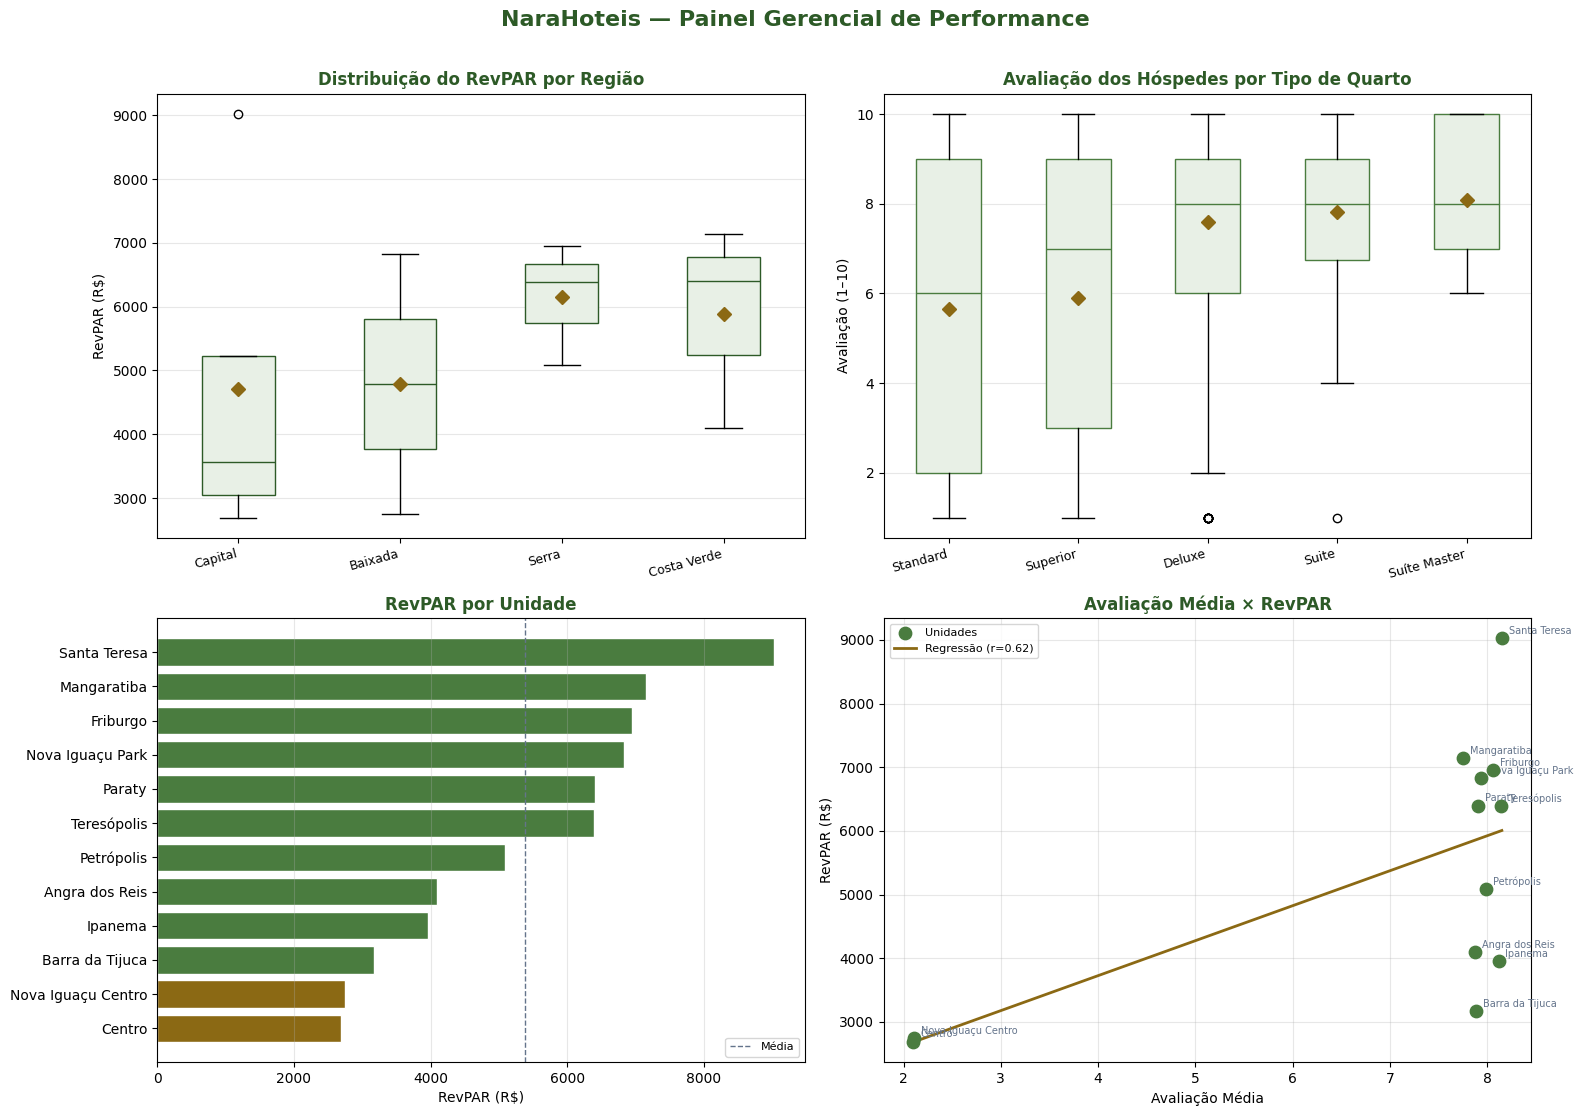

In [432]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("NaraHoteis — Painel Gerencial de Performance", fontsize=16,
             fontweight='bold', color='#2D5A27', y=1.01)

VERDE   = '#2D5A27'
VERDE_M = '#4A7C3F'
DOURADO = '#8B6914'
CINZA   = '#64748B'

# ── Quadrante 1: Boxplot RevPAR por Região ───────────────────────────────────
ax1 = axes[0, 0]

dados_capital = revpar[revpar['regiao'] == 'Capital']['revpar'].values
dados_baixada = revpar[revpar['regiao'] == 'Baixada Fluminense']['revpar'].values
dados_serra   = revpar[revpar['regiao'] == 'Serra']['revpar'].values
dados_verde   = revpar[revpar['regiao'] == 'Costa Verde']['revpar'].values

bp = ax1.boxplot([dados_capital, dados_baixada, dados_serra, dados_verde],
                 vert=True, patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor=DOURADO,
                                markeredgecolor=DOURADO, markersize=7))
for patch in bp['boxes']:
    patch.set_facecolor('#E8F0E6')
    patch.set_edgecolor(VERDE)
for median in bp['medians']:
    median.set_color(VERDE)

ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['Capital', 'Baixada', 'Serra', 'Costa Verde'],
                    rotation=15, ha='right', fontsize=9)
ax1.set_title("Distribuição do RevPAR por Região", fontweight='bold', color=VERDE)
ax1.set_ylabel("RevPAR (R$)")
ax1.grid(axis='y', alpha=0.3)

# ── Quadrante 2: Boxplot Avaliação por Tipo de Quarto ────────────────────────
ax2 = axes[0, 1]

df_tq = df.merge(tipos_quarto[['id_tipo_quarto', 'descricao']], on='id_tipo_quarto', how='left')

dados_std    = df_tq[df_tq['descricao'] == 'Standard']['avaliacao_hospede'].dropna().values
dados_sup    = df_tq[df_tq['descricao'] == 'Superior']['avaliacao_hospede'].dropna().values
dados_dlx    = df_tq[df_tq['descricao'] == 'Deluxe']['avaliacao_hospede'].dropna().values
dados_suite  = df_tq[df_tq['descricao'] == 'Suite']['avaliacao_hospede'].dropna().values
dados_master = df_tq[df_tq['descricao'] == 'Suíte Master']['avaliacao_hospede'].dropna().values

bp2 = ax2.boxplot([dados_std, dados_sup, dados_dlx, dados_suite, dados_master],
                  vert=True, patch_artist=True, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor=DOURADO,
                                 markeredgecolor=DOURADO, markersize=7))
for patch in bp2['boxes']:
    patch.set_facecolor('#E8F0E6')
    patch.set_edgecolor(VERDE_M)
for median in bp2['medians']:
    median.set_color(VERDE_M)

ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_xticklabels(['Standard', 'Superior', 'Deluxe', 'Suite', 'Suíte Master'],
                    rotation=15, ha='right', fontsize=9)
ax2.set_title("Avaliação dos Hóspedes por Tipo de Quarto", fontweight='bold', color=VERDE)
ax2.set_ylabel("Avaliação (1–10)")
ax2.grid(axis='y', alpha=0.3)

# ── Quadrante 3: RevPAR por Unidade (barras horizontais) ────────────────────
ax3 = axes[1, 0]

rev_sorted = revpar.sort_values(by='revpar').reset_index(drop=True)
nomes = rev_sorted['nome_unidade'].str.replace('NaraHoteis ', '')
valores = rev_sorted['revpar']
cores = [DOURADO, DOURADO] + [VERDE_M] * (len(rev_sorted) - 2)

ax3.barh(nomes, valores, color=cores, edgecolor='white')
ax3.axvline(x=float(np.mean(valores)), color=CINZA, linestyle='--', linewidth=1, label='Média')
ax3.set_title("RevPAR por Unidade", fontweight='bold', color=VERDE)
ax3.set_xlabel("RevPAR (R$)")
ax3.legend(fontsize=8)
ax3.grid(axis='x', alpha=0.3)

# ── Quadrante 4: Dispersão Avaliação × RevPAR + Regressão ───────────────────
ax4 = axes[1, 1]

ax4.scatter(analise['avaliacao_media'], analise['revpar'],
            color=VERDE_M, s=80, zorder=5, label='Unidades')

x_linha = np.linspace(analise['avaliacao_media'].min(), analise['avaliacao_media'].max(), 100)
y_linha = a * x_linha + b
ax4.plot(x_linha, y_linha, color=DOURADO, linewidth=2, label=f'Regressão (r={correlacao:.2f})')

for i, row in analise.iterrows():
    ax4.annotate(row['nome_unidade'].replace('NaraHoteis ', ''),
                 (row['avaliacao_media'], row['revpar']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7, color=CINZA)

ax4.set_title("Avaliação Média × RevPAR", fontweight='bold', color=VERDE)
ax4.set_xlabel("Avaliação Média")
ax4.set_ylabel("RevPAR (R$)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../NARA-HOTEIS/tratados/painel_narahoteis.png', dpi=150, bbox_inches='tight')
plt.show()